In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import gamma
import numpy as np


# 1) Exploración y comprensión de los datos:

- Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos:
<hr style="border:1px solid gray">

In [26]:
# Cargamos el dataset de los recorridos realidazos en 2024
df = pd.read_csv("../datasets/badata_ecobici_recorridos_realizados_2024.csv", encoding="utf-8")

# En el sitio web de la BA data se encuentran disponibles los recorridos desde 2018, 
# los datos parciales de 2025. Cargamos el últimmo año completo.
# https://data.buenosaires.gob.ar/dataset/bicicletas-publicas

- Describir las características principales del dataset, incluyendo el número de
observaciones, número de variables y tipos de datos:
<hr style="border:1px solid gray">

In [252]:
print("Dimensiones del dataset:", df.shape)
print("Head:")
display(df.head())

print("Tail:")
display(df.tail())

print("Info:")
print(df.info())

Dimensiones del dataset: (3559284, 17)
Head:


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


Tail:


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
3559279,21526830,506,2024-04-25 21:35:33,93,093 - CARLOS CALVO,Sarandi 1010,-58.394464,-34.620798,2024-04-25 21:43:59,175,147 - Constitución,Avenida Juan de Garay 1050,-58.380707,-34.626851,1124148.0,ICONIC,MALE
3559280,21525192,970,2024-04-25 17:34:30,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-04-25 17:50:40,93,093 - CARLOS CALVO,Sarandi 1010,-58.394464,-34.620798,1124148.0,FIT,MALE
3559281,21525370,1442,2024-04-25 17:45:12,263,270 - PLAZA DEL ANGEL GRIS,Calcena & Avellaneda Av.,-58.457555,-34.622003,2024-04-25 18:09:14,263,270 - PLAZA DEL ANGEL GRIS,Calcena & Avellaneda Av.,-58.457555,-34.622003,870169.0,FIT,MALE
3559282,21526289,520,2024-04-25 19:28:49,222,160 - Godoy Cruz y Libertador,Av. Cerviño 4301,-58.418543,-34.575919,2024-04-25 19:37:29,124,124 - UGARTECHE,Juan María Gutiérrez 2069,-58.412625,-34.581114,222965.0,ICONIC,FEMALE
3559283,21522073,982,2024-04-25 13:13:10,517,332 - PACÍFICO II,Av. Int. Bullrich 300,-58.424814,-34.574501,2024-04-25 13:29:32,50,050 - Hospital Rivadavia,2516 Pereyra Lucena,-58.401080,-34.583735,1148648.0,ICONIC,FEMALE


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3559284 entries, 0 to 3559283
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   id_recorrido                int64  
 1   duracion_recorrido          int64  
 2   fecha_origen_recorrido      object 
 3   id_estacion_origen          int64  
 4   nombre_estacion_origen      object 
 5   direccion_estacion_origen   object 
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     object 
 9   id_estacion_destino         int64  
 10  nombre_estacion_destino     object 
 11  direccion_estacion_destino  object 
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  float64
 15  modelo_bicicleta            object 
 16  genero                      object 
dtypes: float64(5), int64(4), object(8)
memory usage: 461.6+ MB
None


In [253]:
print("Valores nulos por columna:")
print(df.isna().sum())

Valores nulos por columna:
id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido        3379
id_estacion_destino               0
nombre_estacion_destino           0
direccion_estacion_destino        0
long_estacion_destino             0
lat_estacion_destino              0
id_usuario                        0
modelo_bicicleta                  0
genero                        11946
dtype: int64


| Variable                     | Descripción                                                         |Tipo de Variable   |Ejemplo                                     |
| ---------------------------- | ------------------------------------------------------------------- |------------------ |------------------------------------------- |
| `id_recorrido`               | Identificador único de cada recorrido                               |Numérica discreta*  |20428222                                    |
| `duracion_recorrido`         | Duración del recorrido en **segundos**                              |Numérica continua  |568                     |
| `fecha_origen_recorrido`     | Fecha y hora de inicio del recorrido                                |Fecha / Temporal   |2024-01-23 18:36:00                         |
| `id_estacion_origen`         | Identificador numérico de la estación de origen                     |Numérica discreta  |513                                         |
| `nombre_estacion_origen`     | Nombre de la estación de origen (`ID - NOMBRE`)                     |Categórica nominal |308 - SAN MARTIN II                         |
| `direccion_estacion_origen`  | Dirección de la estación de origen                                  |Categórica nominal |Av. San Martín 5129                         |
| `long_estacion_origen`       | Longitud geográfica de la estación de origen (Sistema Geodésico Mundial) | Numérica continua  |    -58.490739       |
| `lat_estacion_origen`        | Latitud geográfica de la estación de origen                         |Numérica continua  |-34.597130                                  |
| `fecha_destino_recorrido`    | Fecha y hora de fin del recorrido (puede ser nulo si quedó abierto) |Fecha / Temporal   |2024-01-23 18:45:28           |
| `id_estacion_destino`        | Identificador numérico de la estación de destino                    |Numérica discreta  |498                                         |
| `nombre_estacion_destino`    | Nombre de la estación de destino (`ID - NOMBRE`)                    |Categórica nominal |055 - HABANA                                |
| `direccion_estacion_destino` | Dirección de la estación de destino                                 |Categórica nominal |Gral. José Gervasio Artigas 4298 (y Habana) |
| `long_estacion_destino`      | Longitud geográfica de la estación de destino                       |Numérica continua  |-58.494959                                  |
| `lat_estacion_destino`       | Latitud geográfica de la estación de destino                        |Numérica continua  |-34.586598                                  |
| `id_usuario`                 | Identificador numérico del usuario (no es el DNI)                   |Numérica discreta  |992557.0                                    |
| `modelo_bicicleta`           | Modelo de la bicicleta utilizada (ej: `FIT`, `ICONIC`)              |Categórica nominal |FIT                                         |
| `genero`                     | Género declarado del usuario (`MALE`, `FEMALE`, `OTHER`, null)      |Categórica nominal |MALE                         |



- Identificar patrones generales y distribuciones:
<hr style="border:1px solid gray">

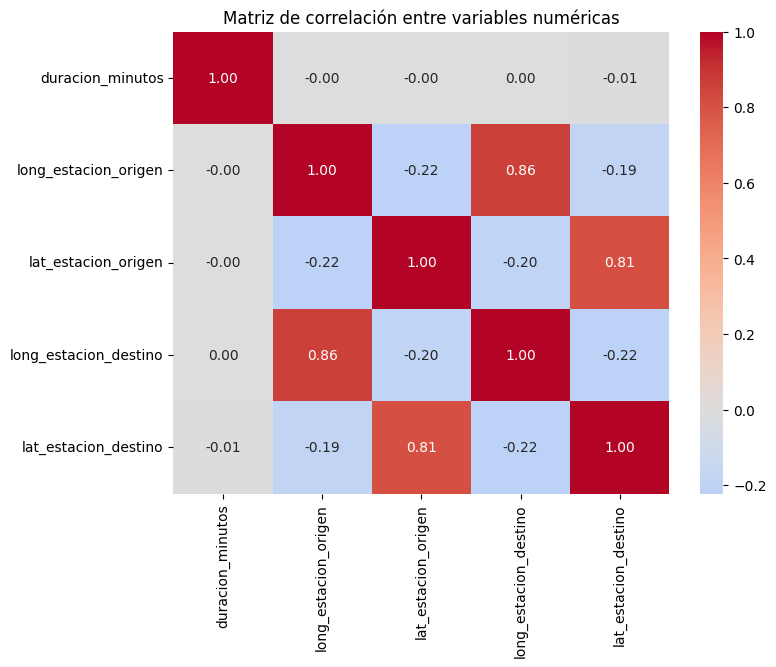

In [27]:
# las columnas de fechas están en formato string, las convertiremos a datetime.
df["fecha_origen_recorrido"] = pd.to_datetime(df["fecha_origen_recorrido"])
df["fecha_destino_recorrido"] = pd.to_datetime(df["fecha_destino_recorrido"])

# columnas dia-semana y hora para visualizar algunos datos por día y hora
df["dia_semana"] = df["fecha_origen_recorrido"].dt.day_name()
df["hora_salida"] = df["fecha_origen_recorrido"].dt.hour
df["hora_llegada"] = df["fecha_destino_recorrido"].dt.hour
df["duracion_minutos"] = df["duracion_recorrido"] / 60
df["hora"] = df["fecha_origen_recorrido"].dt.hour


# Seleccionar variables numéricas
numeric_cols = ["duracion_minutos",
                "long_estacion_origen", "lat_estacion_origen",
                "long_estacion_destino", "lat_estacion_destino"]

# Calcular matriz de correlación
corr = df[numeric_cols].corr()

# Graficar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

# Esto mata la máquina por el tamaño del dataset
#sns.pairplot(data=df_filtrado, hue='nombre_estacion_origen', vars=['duracion_recorrido', 'hora_salida', 'hora_llegada']) 

# Vemos una correlación alta entre las longitudes de las estaciones de origen y destino
# y entre las latitudes de las estaciones de origen y destino.


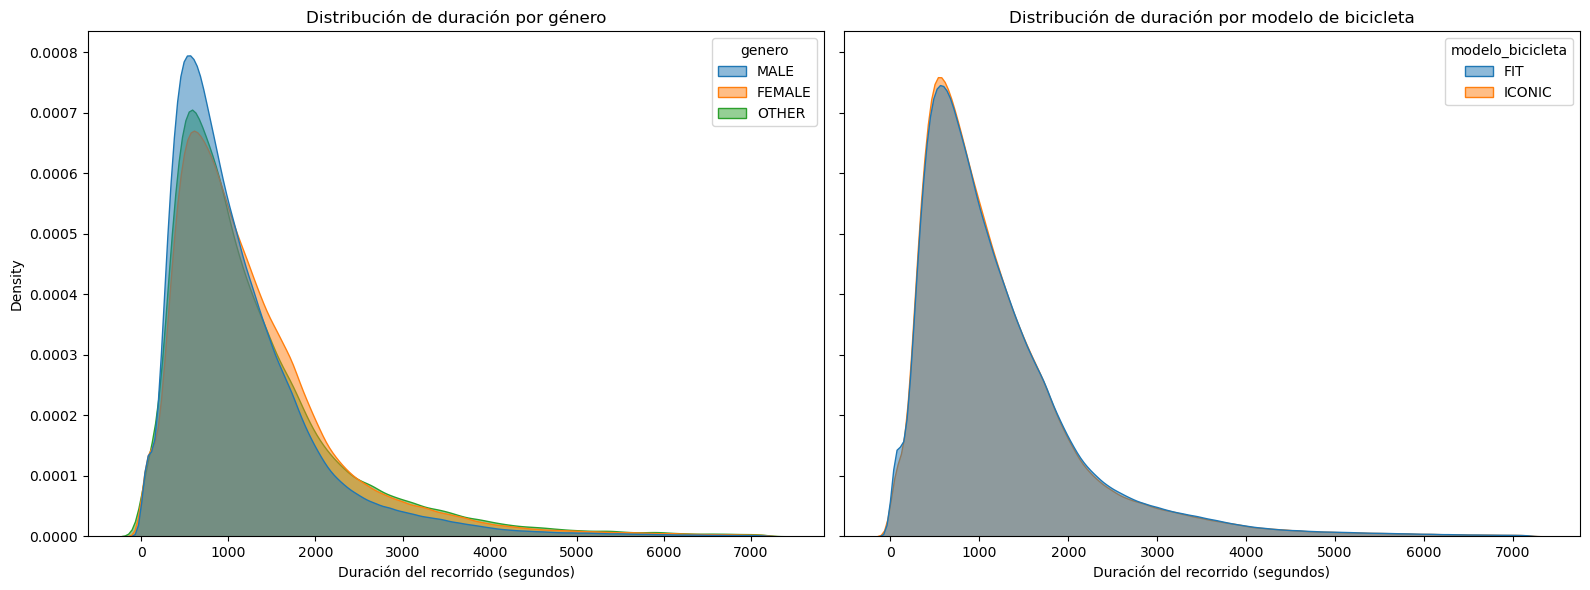

In [255]:
# Veamos si hay relaciones entre la duración de los viajes según el género o el modelo de bicicleta. 

# Se hace un filtrado de viajes razonables 
# porque parece haber muchos outliers

df_filtrado = df[(df["duracion_recorrido"] > 30) # al menos 1 minuto, porque hay muchos outliers que deben devoluciones inmediatas por bicicletas en estado defectuoso
                 &(df["duracion_recorrido"] < 7200)
                ] # analizar los de más de 2 horas 

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Distribución por género
sns.kdeplot(
    data=df_filtrado, 
    x='duracion_recorrido', 
    hue='genero', 
    fill=True, 
    common_norm=False, 
    alpha=0.5, 
    ax=axes[0]
)
axes[0].set_title("Distribución de duración por género")
axes[0].set_xlabel("Duración del recorrido (segundos)")

# Distribución por modelo de bicicleta
sns.kdeplot(
    data=df_filtrado, 
    x='duracion_recorrido', 
    hue='modelo_bicicleta', 
    fill=True, 
    common_norm=False, 
    alpha=0.5, 
    ax=axes[1]
)
axes[1].set_title("Distribución de duración por modelo de bicicleta")
axes[1].set_xlabel("Duración del recorrido (segundos)")

plt.tight_layout()
plt.show()


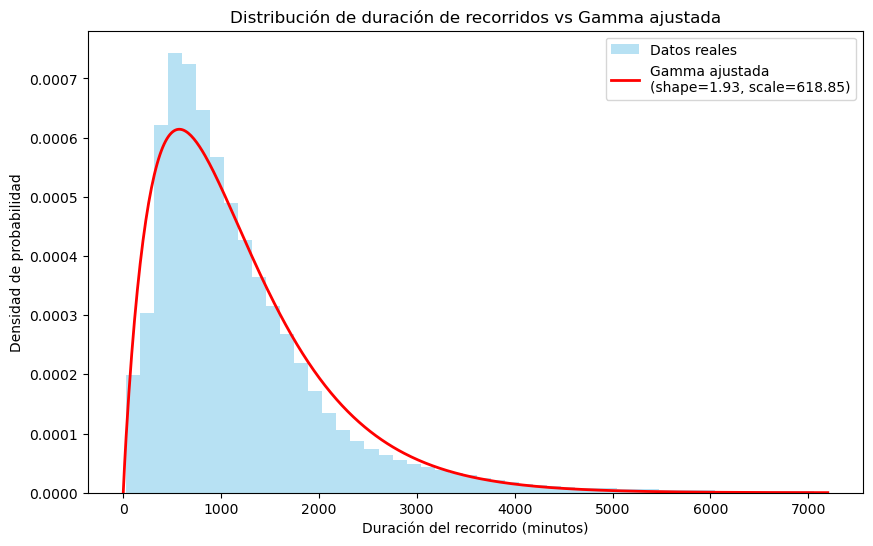

In [256]:
# A simple vista no se relacionan.

# Veamos la distribución de la duración de los viajes y ajustemos una distribución teórica.

duraciones = df["duracion_recorrido"]

# Filtramos valores extremos (ejemplo: viajes mayores a 120 min)
duraciones = duraciones[(duraciones > 25) & (duraciones <= 7200)]

# Ajustar distribución Gamma a los datos
shape, loc, scale = gamma.fit(duraciones, floc=0)  # floc=0 fija la localización en 0

# Crear rango de valores para graficar la curva teórica
x = np.linspace(0, duraciones.max(), 500)
pdf_gamma = gamma.pdf(x, shape, loc=loc, scale=scale)

# Graficar histograma y curva gamma ajustada
plt.figure(figsize=(10,6))
plt.hist(duraciones, bins=50, density=True, alpha=0.6, color="skyblue", label="Datos reales")
plt.plot(x, pdf_gamma, "r-", lw=2, label=f"Gamma ajustada\n(shape={shape:.2f}, scale={scale:.2f})")
plt.xlabel("Duración del recorrido (minutos)")
plt.ylabel("Densidad de probabilidad")
plt.title("Distribución de duración de recorridos vs Gamma ajustada")
plt.legend()
plt.show()

In [257]:
# Verifiquemos la dependencia lineal entre la duracion_recorrido y la duración calculada a partir de las fechas.
df["duracion_calculada"] = (df["fecha_destino_recorrido"] - df["fecha_origen_recorrido"]).dt.total_seconds()

df["duracion_recorrido_diff"] = df["duracion_recorrido"] - df["duracion_calculada"] 

num_rows_na = (df["duracion_recorrido_diff"]).isna().sum()
print("Filas con duracion_calculada diferente de cero:", num_rows_na)

print("Diferentes valores de la duracion_calculada:", df["duracion_recorrido_diff"].unique())


Filas con duracion_calculada diferente de cero: 3379
Diferentes valores de la duracion_calculada: [   0.   nan  369. 1304.   22.  608.   31.  636.  405. 1470.]


- Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR,
MNAR)

    Outliers
    - Viajes muy cortos (`duración_recorrido` < 30 segundos). Podrían ser viajes abortados por bicicletas en mal estado.
    - Viajes muy largos (`duración_recorrido` > 2 horas) Pueden ser fallas estructurales relacionadas con la recolección de la fecha de devolución.

    Calcular proporciones
    
    Valores faltantes y su tipo
    - Hay 3379 registros sin `fecha_destino_recorrido` pero sí tienen id, long y lat de destino. (0.1%). Falla del registro? MCAR / MAR?
    - Hay 11946 registros sin género. Puede ser algo opcional en el registro o una versión antigua de la aplicación. MAR o MNAR?





# Curiosidades

- El id del recorrido se podría excluir de las variables (features), ya que es un identificador único del registro.
- El formato de los nombres de las estaciones contienen un ID que no coincide con la columna `id_estacion`, puede ser un ID de estación de cara al usuario. 
- La duración del recorrido tiene una densidad sesgada a la derecha, con una media de aproximadamente 20 minutos, mediana de 16 minutos, moda de un poco más de 8 minutos y desviación estandar de 15 minutos.
- Se puede verificar la dependencia lineal entre la duración del recorrido y la diferencia entre las fechas de destino y origen.
- La función de densidad de la duración del recorrido se parece a una distribución Gamma con parámetros 1,96 y 618.9.
- El violin plot de la duración del recorrido se parece más a una manta raya que a un violín. Lo que puede tener alguna relación con la distribución.

Es curioso además que el número de filas que no tienen fecha de destino son las mismas para las cuales la `duración_calculada` no coincide con la duración del recorrido (`duracion_recorrido`).

Se podría pensar que ante fallas en las devoluciones, el sistema permite ingresan datos manualmente para esos casos.  

# Desfíos

- El dataset carece de un identificador de la bicicleta lo que eventualmente dificultaría para hacer seguimiento de las mismas.
- El dataset es muy grande, por lo que por ejemplo hace muy ineficiente generar algunos gráficos como el pairplot.
- Realizar predicciones temporales generales dado que hay tendencias relacionadas con horarios de uso. ?


## Análisis de la duración del recorrido:
<hr style="border:1px solid gray">


In [68]:
df_filtrado["duracion_recorrido"].apply(lambda x: x/60).describe()

count    3.236974e+06
mean     1.998089e+01
std      1.545250e+01
min      5.166667e-01
25%      9.700000e+00
50%      1.586667e+01
75%      2.545000e+01
max      1.199833e+02
Name: duracion_recorrido, dtype: float64

In [58]:
df["duracion_recorrido"].apply(lambda x: x/60/60).sort_values(ascending=False).head(10).reset_index(name="Duracion recorrido (hs)")

,index,Duracion recorrido (hs)
0,1912204,714.212500
1,2228576,710.752222
2,3269149,701.810833
3,2437176,692.579722
4,2996925,669.290000
5,2454100,661.350556
6,3289952,660.271667
7,3198811,653.693056
8,1735059,640.229167
9,2178228,635.050000


Estadísticos de duración de viajes (sin filtros y en segundos)
Media: 1274.83
Mediana: 881.00
Moda: 2
Varianza: 91857198.64
Desviación estándar: 9584.22


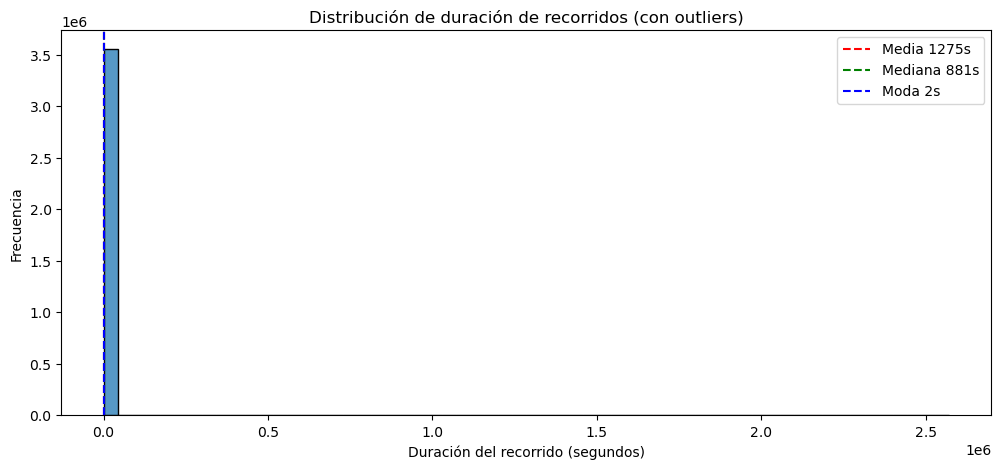

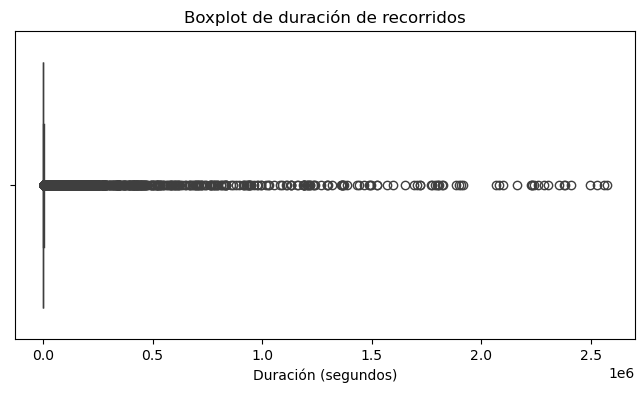

In [258]:
# Estadísticos básicos para la duración del recorrido
media = df["duracion_recorrido"].mean()
mediana = df["duracion_recorrido"].median()
moda = df["duracion_recorrido"].mode()[0]
varianza = df["duracion_recorrido"].var()
desv = df["duracion_recorrido"].std()

print("Estadísticos de duración de viajes (sin filtros y en segundos)")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación estándar: {desv:.2f}")

# Histograma CON OUTLIERS ---
plt.figure(figsize=(12,5))
sns.histplot(df["duracion_recorrido"], bins=60, kde=False)
plt.axvline(media, color='red', linestyle='--', label=f'Media {media:.0f}s')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana {mediana:.0f}s')
plt.axvline(moda, color='blue', linestyle='--', label=f'Moda {moda}s')
plt.xlabel("Duración del recorrido (segundos)")
plt.ylabel("Frecuencia")
plt.title("Distribución de duración de recorridos (con outliers)")
plt.legend()
plt.show()

# Boxplot con outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df["duracion_recorrido"])
plt.xlabel("Duración (segundos)")
plt.title("Boxplot de duración de recorridos")
plt.show()


Estadísticos de duración de viajes (en segundos)
Media: 1198.85
Mediana: 952.00
Moda: 500
Varianza: 859606.80
Desviación estándar: 927.15


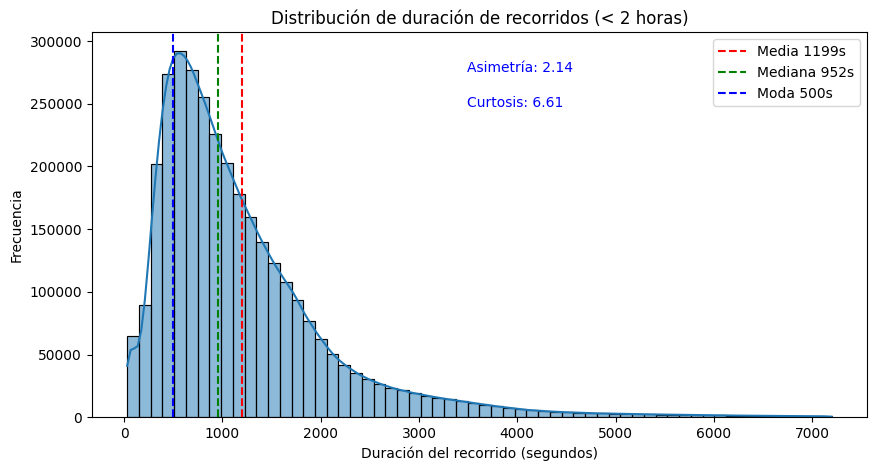

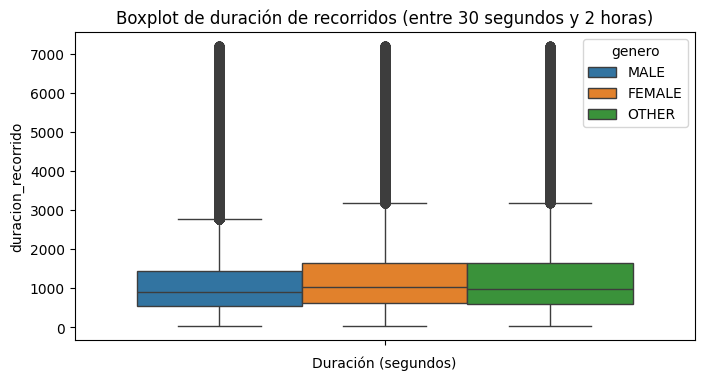

In [ ]:

# Sobre la duración de los viajes

# Se hace un filtrado de viajes razonables 
# porque parece haber muchos outliers


# Estadísticos sin outliers para la duración del recorrido
media = df_filtrado["duracion_recorrido"].mean()
mediana = df_filtrado["duracion_recorrido"].median()
moda = df_filtrado["duracion_recorrido"].mode()[0]
varianza = df_filtrado["duracion_recorrido"].var()
desv = df_filtrado["duracion_recorrido"].std()

print("Estadísticos de duración de viajes (en segundos)")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación estándar: {desv:.2f}")

skewness = df_filtrado["duracion_recorrido"].skew()
kurtosis = df_filtrado["duracion_recorrido"].kurt()

plt.figure(figsize=(10,5))
sns.histplot(df_filtrado["duracion_recorrido"], bins=60, kde=True)
plt.xlabel("Duración del recorrido (segundos)")
plt.ylabel("Frecuencia")
plt.axvline(df_filtrado["duracion_recorrido"].mean(), color='red', linestyle='--', label=f'Media {media:.0f}s')
plt.axvline(df_filtrado["duracion_recorrido"].median(), color='green', linestyle='--', label=f'Mediana {mediana:.0f}s')
plt.axvline(df_filtrado["duracion_recorrido"].mode()[0], color='blue', linestyle='--', label=f'Moda {moda:.0f}s')

plt.figtext(0.5, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
plt.figtext(0.5, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
plt.title("Distribución de duración de recorridos (< 2 horas)")
plt.legend()
plt.show()

# Boxplot para ver valores atípicos
plt.figure(figsize=(8,4))
#sns.boxplot(data=df_filtrado, y="duracion_recorrido")
sns.boxplot(data=df_filtrado, y="duracion_recorrido")
plt.xlabel("Duración (segundos)")
plt.title("Boxplot de duración de recorridos (entre 30 segundos y 2 horas)")
plt.show()


plt.figure(figsize=(8,4))
#sns.boxplot(data=df_filtrado, y="duracion_recorrido")
sns.boxplot(data=df_filtrado, y="duracion_recorrido", hue="genero")
plt.xlabel("Duración (segundos)")
plt.title("Boxplot de duración de recorridos (entre 30 segundos y 2 horas)")
plt.show()


In [260]:
Q1 = df_filtrado['duracion_recorrido'].quantile(0.25)
Q2 = df_filtrado['duracion_recorrido'].quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
Q3 = df_filtrado['duracion_recorrido'].quantile(0.75)

print("Q1 (25%):", Q1)
print("Q2 (Mediana, 50%):", Q2)
print("Q3 (75%):", Q3)

IQR = Q3 - Q1
print("Rango intercuartil (IQR):", IQR)

Q1 (25%): 582.0
Q2 (Mediana, 50%): 952.0
Q3 (75%): 1527.0
Rango intercuartil (IQR): 945.0


<Axes: xlabel='duracion_recorrido'>

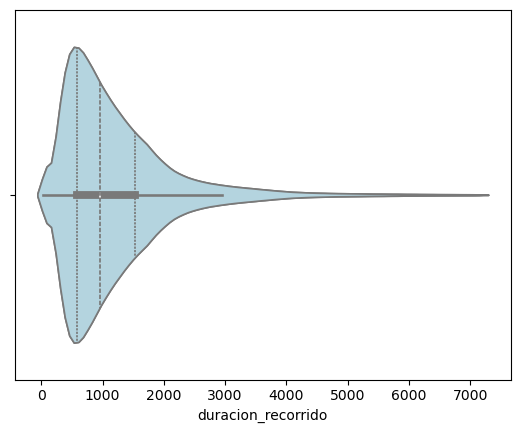

In [261]:
sns.violinplot(data=df_filtrado, x='duracion_recorrido', color="lightblue", inner="box")
sns.violinplot(data=df_filtrado, x='duracion_recorrido', color="lightblue", inner="quartile")

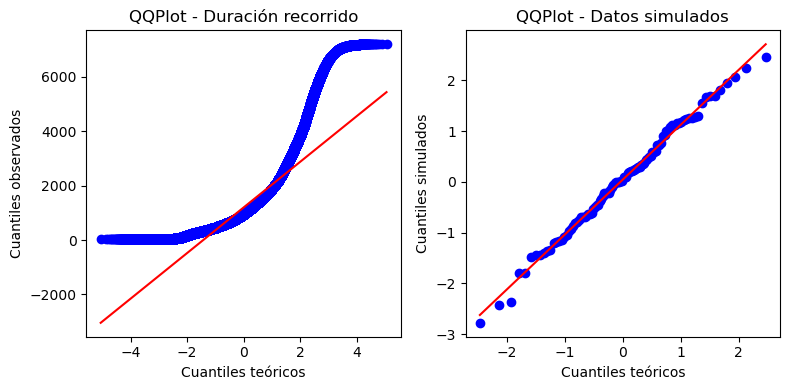

In [262]:
fig, (ax_ping, ax_normal) = plt.subplots(1, 2, figsize=(8, 4))

# QQPlot para la duración de recorrido de aleta de pingüinos
st.probplot(df_filtrado['duracion_recorrido'], dist="norm", plot=ax_ping)
ax_ping.set_title("QQPlot - Duración recorrido")
ax_ping.set_xlabel("Cuantiles teóricos")
ax_ping.set_ylabel("Cuantiles observados")

# QQPlot para datos aleatorios con distribución normal
data = np.random.normal(loc=0, scale=1, size=100)
st.probplot(data, dist="norm", plot=ax_normal)
ax_normal.set_title("QQPlot - Datos simulados")
ax_normal.set_xlabel("Cuantiles teóricos")
ax_normal.set_ylabel("Cuantiles simulados")

plt.tight_layout()
plt.show()

In [263]:
# Observamos que el nombnre de las estaciones tienen el formato compuesto
# "001 - Nombre de la ESTACION"
# Cambiamos los formato de nombres de estaciones

# Los convertimos a "NOMBRE DE LA ESTACION"
df["nombre_estacion_origen"] = df["nombre_estacion_origen"].str.split("-", n=1).str[-1].str.strip().str.upper()
df["nombre_estacion_destino"] = df["nombre_estacion_destino"].str.split("-", n=1).str[-1].str.strip().str.upper()

In [264]:
# Agrupamos por estación, día y hora (flujo de salidas)
salidas = (
    df.groupby(["nombre_estacion_origen", "dia_semana", "hora_salida"])
    .size()
    .reset_index(name="cantidad_salidas")
)

llegadas = (
    df.groupby(["nombre_estacion_destino", "dia_semana", "hora_llegada"])
    .size()
    .reset_index(name="cantidad_llegadas")
)

In [265]:
# Agrupamos por estación, día y hora (flujo de salidas)
salidas = (
    df.groupby(["nombre_estacion_origen", "dia_semana", "hora_salida"])
    .size()
    .reset_index(name="cantidad_salidas")
)

llegadas = (
    df.groupby(["nombre_estacion_destino", "dia_semana", "hora_llegada"])
    .size()
    .reset_index(name="cantidad_llegadas")
)

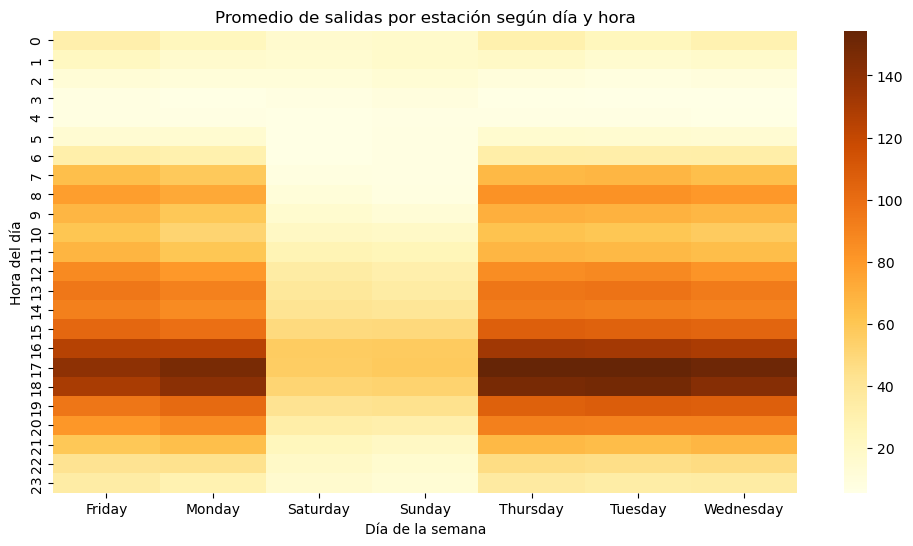

In [266]:
# Mapa de calor de las salidas: promedio de salidas por día y hora
pivot_salidas = salidas.pivot_table(
    index="hora_salida", columns="dia_semana", values="cantidad_salidas", aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_salidas, cmap="YlOrBr", annot=False)
plt.title("Promedio de salidas por estación según día y hora")
plt.ylabel("Hora del día")
plt.xlabel("Día de la semana")
plt.show()

In [36]:
df["nombre_estacion_origen"].describe()

count                3559284
unique                   395
top       147 - Constitución
freq                   38237
Name: nombre_estacion_origen, dtype: object

In [44]:
df["nombre_estacion_origen"].value_counts().head(10).reset_index(name="Frecuencia")

,nombre_estacion_origen,Frecuencia
0,147 - Constitución,38237
1,014 - Pacifico,37594
2,368 - PLAZA DE LA SHOÁ,37201
3,005 - Plaza Italia,34547
4,001 - FACULTAD DE DERECHO,30955
5,008 - Congreso,30400
6,130 - RETIRO II,29307
7,152 - JULIETA LANTERI,28197
8,255 - BARRANCAS DE BELGRANO,27721
9,131- HOSPITAL DE CLÍNICAS,26967


In [45]:
df["nombre_estacion_destino"].value_counts().head(10).reset_index(name="Frecuencia")

,nombre_estacion_destino,Frecuencia
0,147 - Constitución,38281
1,368 - PLAZA DE LA SHOÁ,37425
2,014 - Pacifico,37278
3,005 - Plaza Italia,34606
4,001 - FACULTAD DE DERECHO,30894
5,008 - Congreso,30536
6,152 - JULIETA LANTERI,29036
7,130 - RETIRO II,29027
8,255 - BARRANCAS DE BELGRANO,28047
9,096 - Carlos Gardel,27075


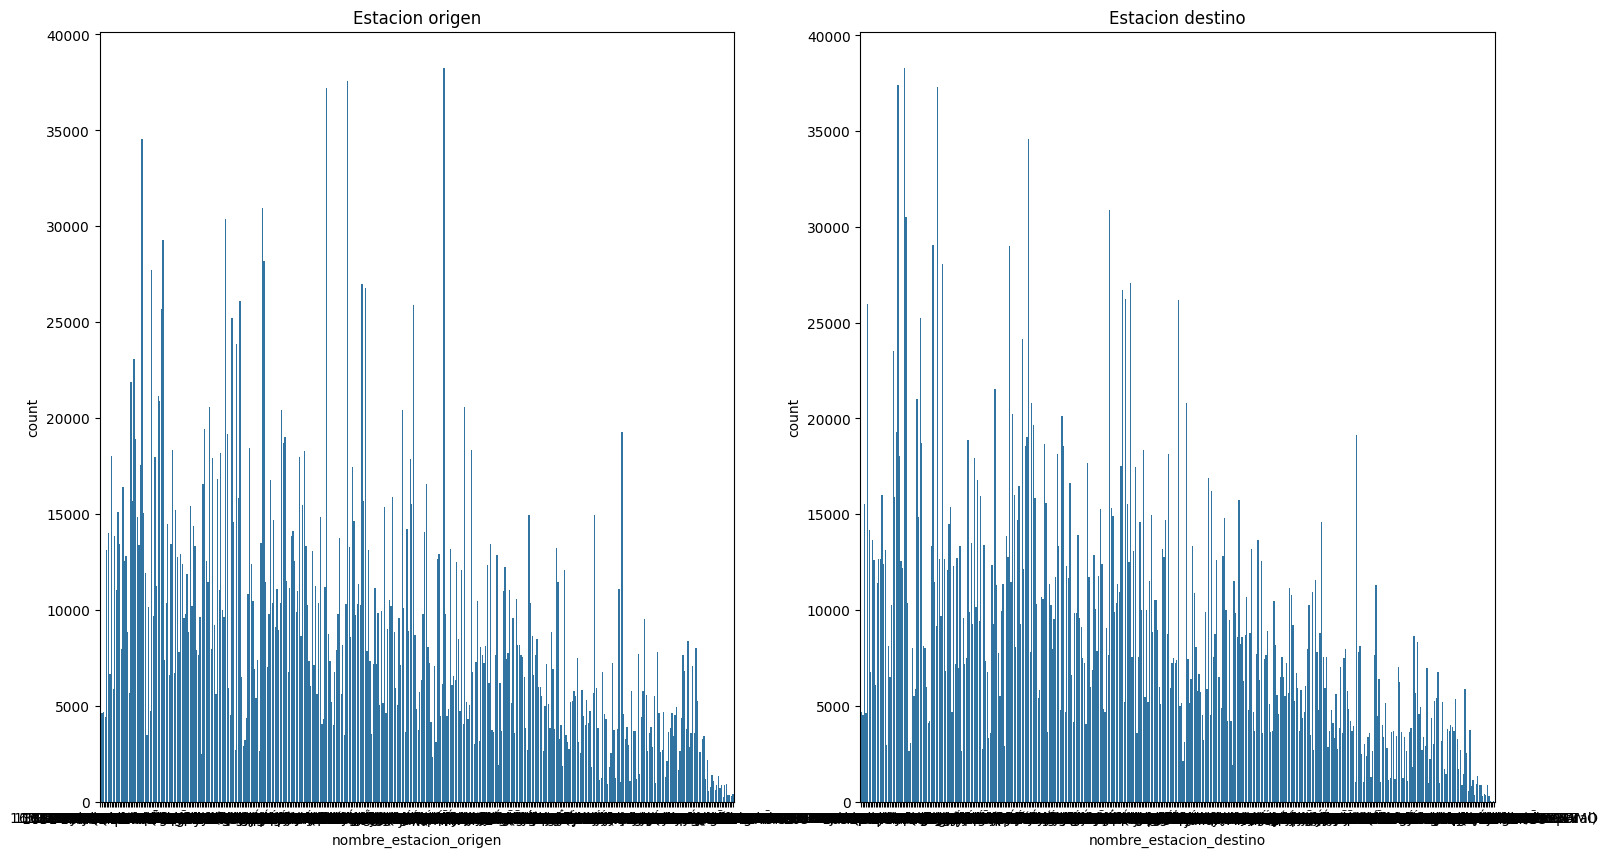

In [48]:
# Crear cada cajita
fig, ax = plt.subplots(1, 2, figsize=(18, 10))

# Gráficos de barras de cada una
sns.countplot(x='nombre_estacion_origen', data=df, ax=ax[0])
sns.countplot(x='nombre_estacion_destino', data=df, ax=ax[1])

# Títulos
ax[0].set_title('Estacion origen')
ax[1].set_title('Estacion destino')

plt.show()

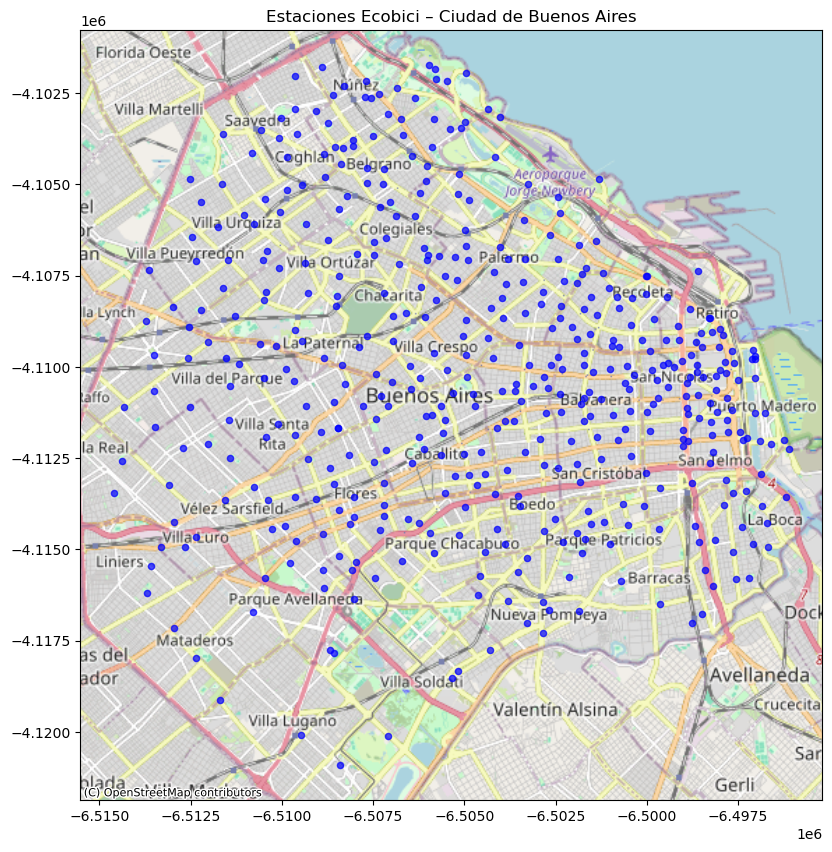

In [267]:
# Estaciones en el mapa de la ciudad

import geopandas as gpd
import contextily as ctx

# Archivo GeoJSON con estaciones
# https://cdn.buenosaires.gob.ar/datosabiertos/datasets/transporte-y-obras-publicas/estaciones-bicicletas-publicas/nuevas-estaciones-bicicletas-publicas.geojson
gdf = gpd.read_file("../datasets/estaciones_bicicletas_publicas.geojson")

# Convertir a Web Mercator (requerido por contextily)
gdf = gdf.to_crs(epsg=3857)

# Plot estaciones con mapa base
ax = gdf.plot(figsize=(10,10), color='blue', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("Estaciones Ecobici – Ciudad de Buenos Aires")
plt.show()

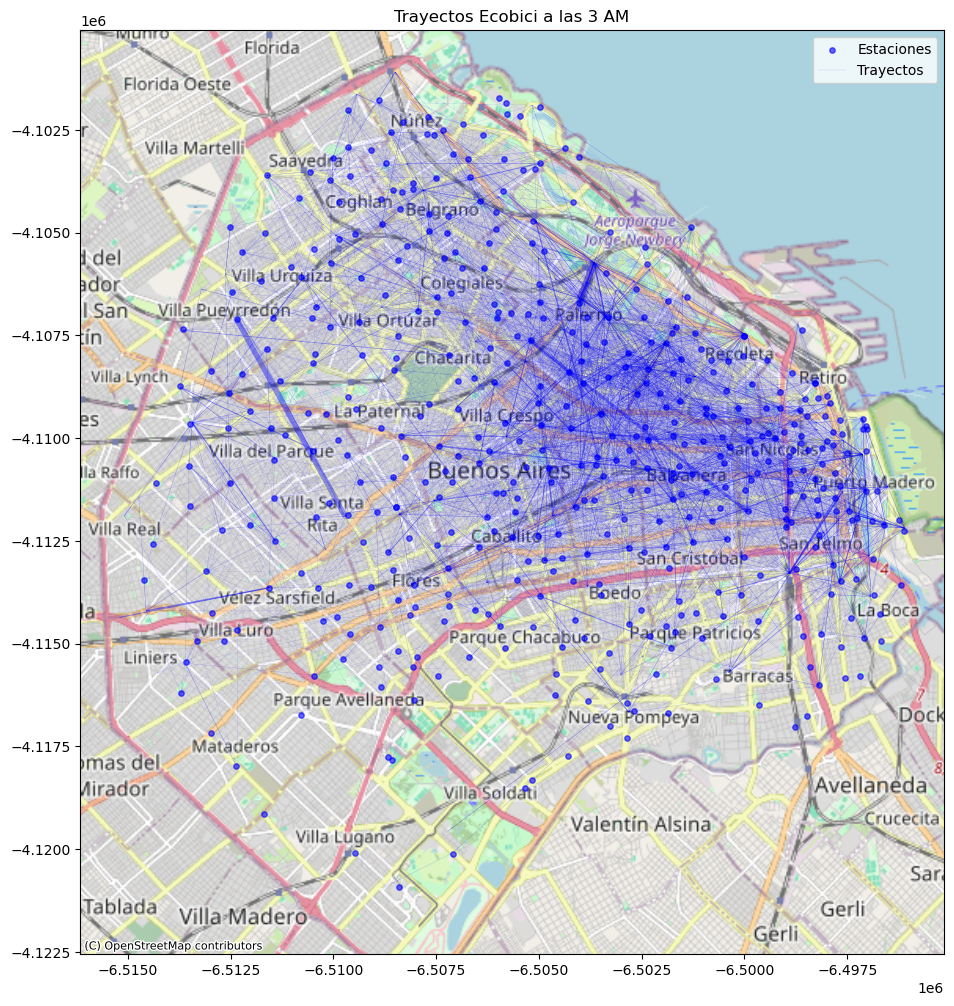

In [268]:
# Trayectos entre estaciones en un horario específico
from shapely.geometry import LineString

filtro_hora = 3 # 3 AM
df_filtrado = df[
    (df["hora_salida"] == filtro_hora)
    #& (df["dia_semana"] == 'Monday')
    ] # También se puede filtrar por día de la semana.

# Agrupamos por pares de estaciones
df_grouped = df_filtrado.groupby(
    ["id_estacion_origen", "id_estacion_destino",
     "long_estacion_origen", "lat_estacion_origen",
     "long_estacion_destino", "lat_estacion_destino"]
).size().reset_index(name="cantidad_viajes")

# Geometría de líneas
df_grouped["geometry"] = df_grouped.apply(
    lambda row: LineString([
        (row['long_estacion_origen'], row['lat_estacion_origen']),
        (row['long_estacion_destino'], row['lat_estacion_destino'])
    ]), axis=1
)

gdf_lines = gpd.GeoDataFrame(df_grouped, geometry="geometry", crs="EPSG:4326")

# Estaciones (geojson)
# ya están cargadas con 
# gdf = gpd.read_file("estaciones_bicicletas_publicas.geojson") y #gdf = gdf.to_crs(epsg=3857)

gdf_lines = gdf_lines.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(12,12))
gdf.plot(ax=ax, color="blue", markersize=15, alpha=0.6, label="Estaciones")

# Grosor proporcional a cantidad de viajes
gdf_lines.plot(
    ax=ax,
    linewidth=(gdf_lines["cantidad_viajes"] / gdf_lines["cantidad_viajes"].max()) * 5,
    alpha=0.4,
    color="blue",
    label="Trayectos"
)

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.title(f"Trayectos Ecobici a las {filtro_hora} {'AM' if filtro_hora < 12 else 'PM'}")
plt.legend()
plt.show()


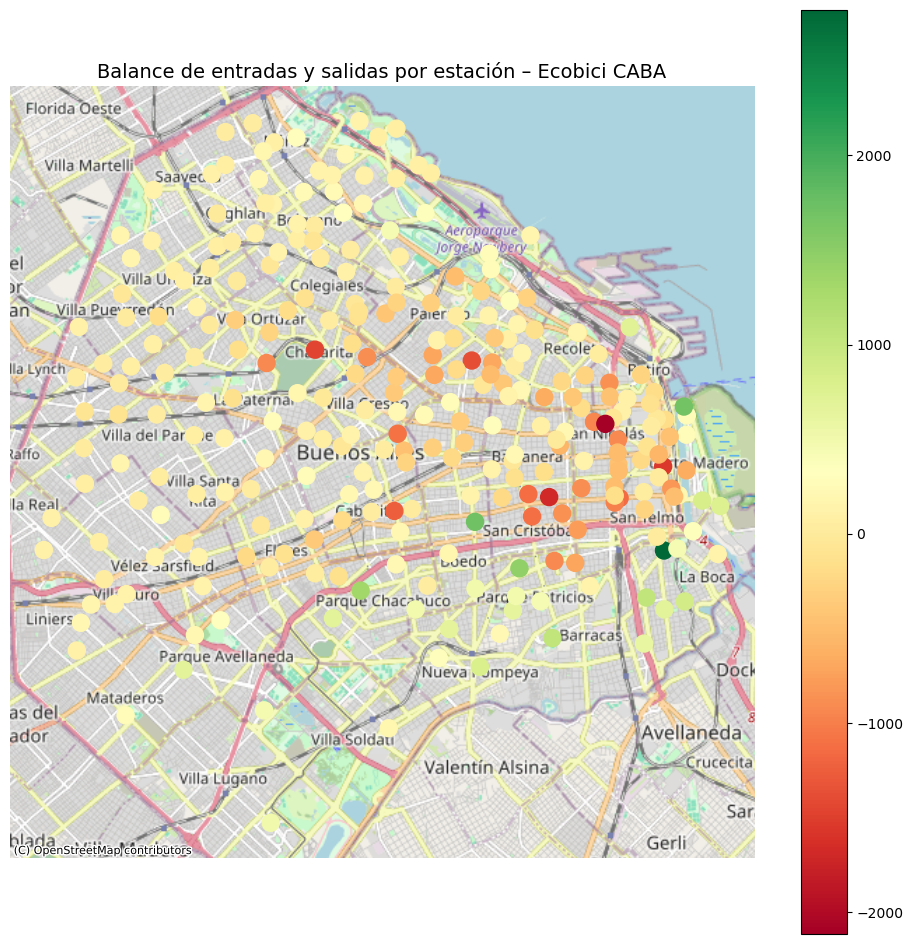

In [269]:
# Calculamos balance de entradas y salidas por estación

# Salidas
agregado = df.groupby('nombre_estacion_origen').size().reset_index(name='salidas')

# Llegadas
df_dest = df.groupby('nombre_estacion_destino').size().reset_index(name='llegadas')

# Merge salidas + llegadas
agg = pd.merge(
    agregado,
    df_dest,
    left_on='nombre_estacion_origen',
    right_on='nombre_estacion_destino',
    how='outer'
).fillna(0)

# Balance
agg['balance'] = agg['llegadas'] - agg['salidas']

# Estaciones con GeoJSON
merged = gdf.merge(agg, left_on='NOMBRE', right_on='nombre_estacion_origen')
merged = merged.to_crs(epsg=3857)

# Mapa base
fig, ax = plt.subplots(figsize=(12, 12))

merged.plot(
    column='balance',
    cmap='RdYlGn',
    legend=True,
    markersize=150,
    #alpha=0.8,
    ax=ax
)

# Agregar mapa de fondo
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Balance de entradas y salidas por estación – Ecobici CABA", fontsize=14)
plt.show()

# Un balance muy negativo indica que la estación tiene más salidas que llegadas
# Esto puede sugerir que no son muy dispobles para tomar bicicletas?
# También podríamos realizar este análisis por horario. 